# Linear Regression

## Objectives

1. Explore the working of **GridSearchCV**.
2. Explore and understand the concept of **Cross Validation**.
3. Explore Ridge Regression and obtain optimal **hyperparamaters** using GridSearchCV.

---

### Recap

In previous notebook we explored the concepts of Linear Regression with:

1. Simple Linear Regression
2. Multiple Linear Regression 

Let us run the code for Multiple Linear Regression performed on the Boston house pricing dataset.

In [14]:
# Import standard packages

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn')

import warnings
warnings.filterwarnings('ignore')

# Import the corresponding library
from sklearn.linear_model import LinearRegression

# Instantiating a model object named 'model'
model = LinearRegression(normalize=True)

# Import Scikit-Learn module
import sklearn

# Load the Boston house pricing dataset
from sklearn.datasets import load_boston
sklearn.set_config(print_changed_only=True)

# Arrange the dataset into features and target 
boston = load_boston()
X, y = boston.data, boston.target

# Displahy the dataset description
# print(boston.DESCR)

# Perform the train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Fit the Regression model
model.fit(X_train, y_train)

# Obtain the model predictions for the test dataset
y_pred = model.predict(X_test)

# Obtain the R-Squared performace metric
train_score_lr = model.score(X_train, y_train)
test_score_lr = model.score(X_test, y_test)

print("The train score for linear regression model is: ", np.round(train_score_lr, 2))
print("The test score for linear regression model is: ", np.round(test_score_lr, 2))

The train score for linear regression model is:  0.75
The test score for linear regression model is:  0.68


Here we notice that the model performance on the train dataset is better when compared with test dataset. 

**Ques:** Can we further improve the model performance?

**Ans:** Yes, it can be done with the help of Regularization (hyperparameter tuning)

To recall, L2 regularization is used to control the fit of the model by penalizing it for errors. Mathematically, linear model can be written as:

\begin{align}
J(\theta) =  \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2
\end{align}

The L2 regularization adds in a weighted loss function as an additional term to control the fitting/learning of the model. Mathematically, (Ridge) L2 regularization model can be written as:

\begin{align}
J(\theta) =  \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2 + \alpha\sum_{j=1}^{n}(\theta)^2
\end{align}

---

**Ques:** It seems that performance of the regularization is governed by $\alpha$. Do we have to initiate a for loop in order to find its optimal value or is there any other method to do the same.

**Ans:** Yes, Instead of using `for` loop for recursive search `scikit learn` offers a powerful tool called `GridSearchCV`


**GridSearchCV**

`GridSearchCV` is a library function of `sklearn.model_selection` package. It helps us to loop through predefined hyperparameters and fit your model on the dataset. So that, we ca select the best parameters from the listed hyperparameters. (In our case it will be the value of $\alpha$)

In simpler words, we will run the model for various values of $\alpha$ in order to obtain the optimal value though which the model gives best performance metrics for both the train and test datasets.

For detailed information: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html 

The `GridSearchCV` takes the following arguments:

- `estimator`: the estimator instance from scikit learn. In our case this will be `Ridge_model()`.

- `param_grid`: the dictionary object that holds the hyperparameters you want to try. In our case this will be different values of $\alpha$

- `cv`: number of cross-validation you have to try for each selected set of hyperparameters (default = 5)

- `return_train_score`: To retain the training scores for each of the $k$ cross folds the estimator has been applied on.

- `verbose`: you can set it to 1 to get the detailed printout while you fit the data to GridSearchCV

- `n_jobs`: number of processes you wish to run in parallel for this task if it -1 it will use all available processors.

---

**Ques:** What is **Cross-Validation** which appears to be an important part of `GridSearchCV()`

**Ans:** 

First let us understand the term Validation. 

Whenever, we create a supervised machine learning model, we divide the available dataset into `train` and `test` dataset.

 - First we use the `train` dataset to generate the model on the corresponding dataset. The model always performs well on it since the model has seen all the datapoints and is based on these only.

 - To check the performance of this developed model, we use `test` dataset which the generated model has never encountered before, and hence helps us to assess the performance on the datapoints that lie outside the `train` datapoints.
 
 - This means, for a good model the performance metrics on `test` dataset should be fairly similar to the train dataset. If this is not the case it implies that the developed model cannot be used for making predictions.


This process is called **validation**: When we try to validate (cross-check) the performance of the developed model using a dataset which our model has not seen before.

- However, there exists a number of real-world situations where validation on the developed model is not enough, and we cannot  guarantee that the model will be robust and perform well in real-world.

- To overcome this challenge we use `cross-validation`. This technique ensures that the developed model is not biased to train-test split and performs robustly with real-world data.

#### K-fold cross validation

In `k-fold cross validation` the dataset is randomly splitted into $k$ (subsets) `folds`. For each fold in the dataset:

- Build the model on $k-1$ folds as train dataset and $k^{th}$ fold as test dataset.

- This process is repeated $k$ times until each of the `k folds` are utilised as both train/test datasets.

- The average of the $k$ recorded accuracy is termed as `cross-validation` accuracy and serves as a performance evaluation metric for the model.

For eg. a **5 fold cross validation** dataset will work as:

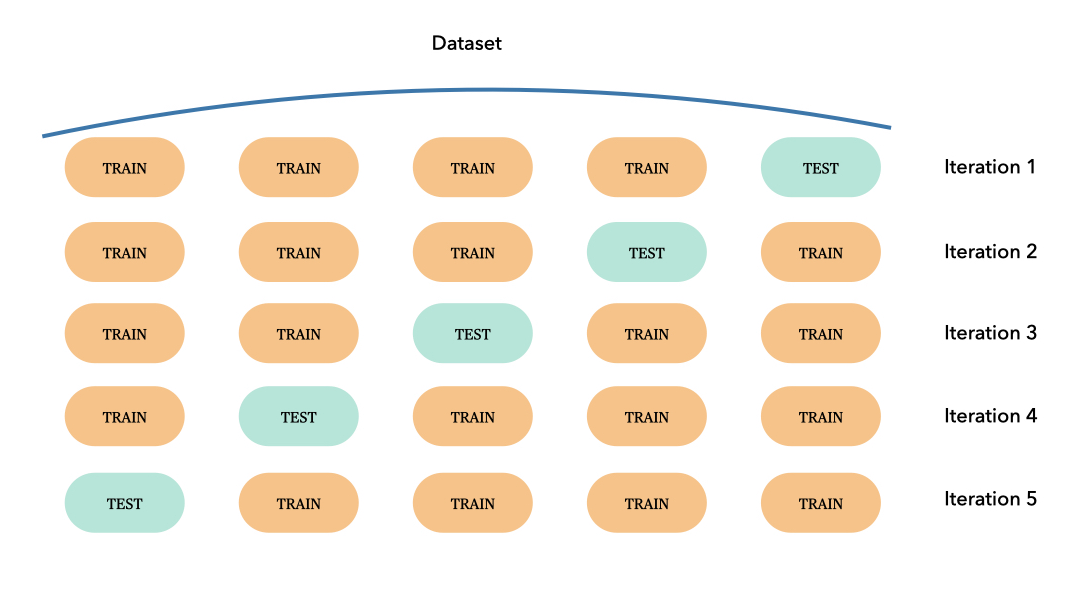

- K fold cross validation technique ensures that every datapoint appears in both:
  - Train set 
  - Test set

However, biggest challenge with k fold cross validation is that it takes $k$ times more computational resources/time to model.

---

### Ridge Regression using GridSearchCV

Let's use `GridSearchCV` for Ridge regression on the Boston house pricing dataset.

For this first let us import the corresponding modules:

1. `Ridge` from the scikit learn `linear_model` module.
2. `GridSearchCV` from the scikit learn `model_selection` module.
3. `cross_val_score` from the scikit learn `model_selection` module.

In [2]:
# Import the required packages
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

One of the important part of GridSearchCV is to define the `grid` for which we want to assess the model performance. 


To recall in Ridge regression model: $J(\theta) =  \frac{1}{m} \sum_{i=1}^{m}(\hat{y}_i - y_i)^2 + \alpha\sum_{j=1}^{n}(\theta)^2$

We will vary the value of $\alpha$ using GridSearchCV so that we get the regression model that exhibits maximum possible scores for the train and test datasets.

To reduce the computation time let us define 14 points for which we will run the GridSearchCV, post this we will analyse the performance of the regression model.

---

Define dictionary, say `param_grid` to select various values for $\alpha$ for which the regression model will be fitted to the dataset.

  - `param_grid = {'alpha': np.logspace(-3, 3, 14)}`

Verify the grid using `print()` command.

In [3]:
# Declare the range of alpha for which you need to run the model
param_grid = {'alpha': np.logspace(-3, 3, 14)}
print(param_grid)

{'alpha': array([1.00000000e-03, 2.89426612e-03, 8.37677640e-03, 2.42446202e-02,
       7.01703829e-02, 2.03091762e-01, 5.87801607e-01, 1.70125428e+00,
       4.92388263e+00, 1.42510267e+01, 4.12462638e+01, 1.19377664e+02,
       3.45510729e+02, 1.00000000e+03])}


1. Construct a regression model grid `grid` using `GridSearchCV` function with following inputs:

 - `Ridge()`: The regression model we want to deploy.
 
 - `param_grid`: The set of parameters for which model performance would be evaluated.

 - `cv` : To specify the number of folds you want the dataset to splitted into.
 
 - `return_train_score`: To retain the training scores so that we can plot them and visually analyze the effect of $\alpha$ on the regularaization model.

2. Call the `fit()` function on the `grid` to find the best fit.

 - Use `X_train` and `y_train` as input.

In [4]:
# Create a grid and fit the dataset
grid = GridSearchCV(Ridge(), param_grid, cv=10, return_train_score=True)
grid.fit(X_train, y_train)

# Obtain the model parameters with highest scores
print(grid.best_params_)
print(grid.best_score_)

{'alpha': 0.07017038286703829}
0.7160650703158148


Here we observe that the best R-squared score we can get is $0.71$ which we get for $\alpha = 0.07$.

**NOTE**: This score is on the test set, when the GridSearchCV splits the provided dataset for cross-validation.

Let us plot the test and train scores for the grid to analyze the performance of the regression with respect to value of $\alpha$. For this:

1. Convert the `grid.cv_results_` to a pandas DataFrame.
2. Plot the `mean_train_score` and `mean_test_score` using `results.plot()` and select the current axes using `ax=plt.gca()`
3. Convert the x-axis into log scale

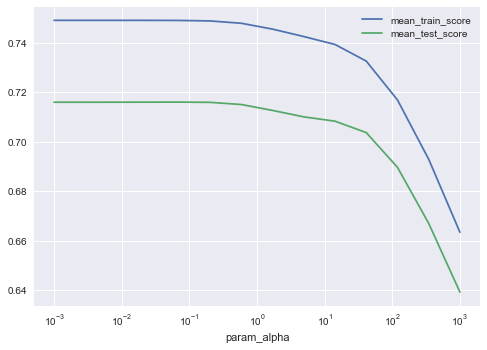

In [5]:
# Convert the grid results into a DataFrame and plot the train and test scores
results = pd.DataFrame(grid.cv_results_)
results.plot('param_alpha', 'mean_train_score', ax=plt.gca())
results.plot('param_alpha', 'mean_test_score', ax=plt.gca())
plt.legend()

# Provide legend to plot and cpnvert x-axis to logarithmic scale
plt.xscale("log")

You can repeat the same activity for a greater number of values for the parameter $\alpha$ and plot the scores.

---

Now, let us build a Ridge regression model with the parameters returned by GridSearchCV $\alpha = 0.07$ and check the scores of the developed model for the test split performed in the original `train_test_split`.

In [6]:
# Create a ridge model with alpha=0.07
ridge = Ridge(alpha=0.07).fit(X_train, y_train)

# Obtain the model predictions for the test dataset
y_pred = ridge.predict(X_test)

# Obtain the R-Squared performace metric
train_score_ridge = ridge.score(X_train, y_train)
test_score_ridge = ridge.score(X_test, y_test)

print("The train score for ridge regression model is: ", np.round(train_score_ridge, 2))
print("The test score for ridge regression model is: ", np.round(test_score_ridge, 2))

The train score for ridge regression model is:  0.75
The test score for ridge regression model is:  0.68


From these scores we can say that there is no observable difference in the scores. That is largely due to the small value of $\alpha$. Hence, it seems GridSearchCV alone will not provide us better results. Let us proceed with some feature engineering to further improve the regression. 

### Feature Engineering

As we saw in the scatterplot a lot of features did not display a clear relationship to the price. Let us use *Polynominal Feature Transform* for preprocessing.

Polynomial features are created by raising the existing features to an exponent. For instance a dataset having $2$ feature columns as: $[x_0, x_1]$ will be converted to: 

- $[1 , x_0 , x_1 , x_0^2 , x_0 \cdot x_1 , x_1^2]$ if we choose `degree = 2` for ploynomial features. 


`PolynomialFeatures` takes the following arguments:

- `degree`: int, `default=2`. If a single int is given, it specifies the maximal degree of the polynomial features. 
- `interaction_only`: bool, default=False. 
        If True, only interaction features are produced: features that are products of at most degree distinct input features, i.e. terms with power of 2 or higher of the same input feature are excluded:
- `include_bias`: bool, default=True
        If True (default), then include a bias column, the feature in which all polynomial powers are zero (i.e. a column of ones - acts as an intercept term in a linear model).

For this:

1. Import `PolynomialFeatures` and `scale` from scikit learns `preprocessing` module
2. Generate new feature set, say `X_poly` from scaled features set `X` using `PolynomialFeatures(include_bias=False).fit_transform(scale(X))`
3. Optional: Check the shape of generated feature set.
4. Finally, split the new feature set into train, test datapoints.

**TIP:** Since, we are working on regression problem, it is better to set `include_bias=False` to avoid multiple intercepts during the model fitting.

<br>

For further reading on Polynomial Features visit [Official scikit documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)

In [7]:
# Import the reqquired packages
from sklearn.preprocessing import PolynomialFeatures, scale

# Generate polynomial features
X_poly = PolynomialFeatures(include_bias=False).fit_transform(scale(X))

# Check the shape of the generated feature set
print(X_poly.shape)

# Perform the train test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, random_state=42)

(506, 104)


Now, that we have imporved feature set. Let us analyze the impact of the feature engineering on **linear regression**. 

Let us fit the linear regression model on the new train set using cross-validation method. For this:

1. Create a variable say, `linear_score` assign it the mean R-squared score generated from the `cross_val_score()`.

2. Set `cv = 10` for creating a 10-fold corss validation set.

3. Pass the respective train sets to the model.

4. Print the score for mean score for the developed model


In [8]:
# Develop the cross validation based linear regression model and obtain mean score
linear_score = np.mean(cross_val_score(LinearRegression(), X_train, y_train, cv=10))

print('R-squared score for feature engineered regression model is: ', linear_score)

R-squared score for feature engineered regression model is:  0.8062549056216686


Here we observe that the score has imporoved and we are getting a higher score for the feature engineered dataset.

Next, let us examine the performance of the ridge regression model on the feature engineered dataset.

In [9]:
# Create a grid and fit the dataset
grid = GridSearchCV(Ridge(), param_grid, cv=10, return_train_score=True)
grid.fit(X_train, y_train)

# Obtain the model parameters with highest scores
print(grid.best_params_)
print(grid.best_score_)

{'alpha': 14.251026703029993}
0.8578415451523966


Here we observe that the best R-squared score we can get is $0.86$ which we get for $\alpha = 14.25$.

**NOTE**: This score is on the test set, when the GridSearchCV splits the provided dataset for cross-validation.

Let us plot the test and train scores for the grid to analyze the performance of the regression with respect to value of $\alpha$. For this:

1. Convert the `grid.cv_results_` to a pandas DataFrame.
2. Plot the `mean_train_score` and `mean_test_score` using `results.plot()` and select the current axes using `ax=plt.gca()`
3. Convert the x-axis into log scale

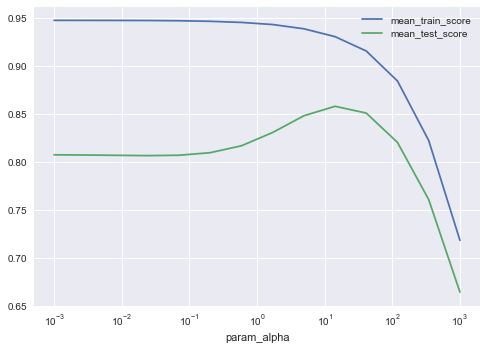

In [10]:
# Convert the grid results into a DataFrame and plot the train and test scores
results = pd.DataFrame(grid.cv_results_)
results.plot('param_alpha', 'mean_train_score', ax=plt.gca())
results.plot('param_alpha', 'mean_test_score', ax=plt.gca())
plt.legend()

# Provide legend to plot and cpnvert x-axis to logarithmic scale
plt.xscale("log")

Here we observe that the train set accuracy remains fairly constant before tapering off but the the test set accuracy has a peak at around $14$ which is also evident from the `grid.best_params_`.

Now, let us build a Ridge regression model with the parameters returned by GridSearchCV $\alpha = 0.14.25$ and check the scores of the developed model for the test split performed in the original `train_test_split`.

In [11]:
# Create a ridge model with alpha=14.25
ridge = Ridge(alpha=14.25).fit(X_train, y_train)

# Obtain the model predictions for the test dataset
y_pred = ridge.predict(X_test)

# Obtain the R-Squared performace metric
train_score_ridge = ridge.score(X_train, y_train)
test_score_ridge = ridge.score(X_test, y_test)

print("The train score for feature engineered ridge regression model is: ", np.round(train_score_ridge, 2))
print("The test score for feature engineered ridge regression model is: ", np.round(test_score_ridge, 2))

The train score for feature engineered ridge regression model is:  0.93
The test score for feature engineered ridge regression model is:  0.81


Here we see that the ridge regression model outperform linear regression and exhibits higher performance scores.

We can also see how the regression model coefficients vary with variation in the value of $\alpha$. For this:

1. Create ridge regression models for say $\alpha = 1$, $\alpha = 14$, and $\alpha = 100$
2. Plot the coefficients for the respective ridge model using `Ridge.coed_` and provide appropriate lables.

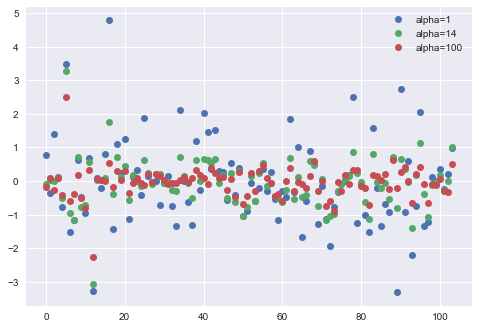

In [12]:
# Develop ridge models for various values of alpha
ridge100 = Ridge(alpha=100).fit(X_train, y_train)
ridge14 = Ridge(alpha=14).fit(X_train, y_train)
ridge1 = Ridge(alpha=1).fit(X_train, y_train)

# Plot the coefficients for the various ridge models
plt.plot(ridge1.coef_, 'o', label="alpha=1")
plt.plot(ridge14.coef_, 'o', label="alpha=14")
plt.plot(ridge100.coef_, 'o', label="alpha=100")
plt.legend();

From the above plot we can observe that with higher values of $\alpha$ the value of coefficients strat to diminish thereby producing lower performance scores for the regression model.

Let's stop here. For next project we will proceed with Classifier design.